In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Service Logic (M/M/s Core Formulas)

In [2]:
def calculateP0(lambd, mu, s):
    sumTerm = sum([(lambd / mu) ** n / math.factorial(n) for n in range(s)])
    lastTerm = ((lambd / mu) ** s) / (math.factorial(s) * (1 - (lambd / (s * mu))))
    return 1 / (sumTerm + lastTerm)

def calculateLq(lambd, mu, s, p0, rho):
    numerator = p0 * ((lambd / mu) ** s) * rho
    denominator = math.factorial(s) * ((1 - rho) ** 2)
    return numerator / denominator

def calculateQueueMetrics(row, sOverride=None):
    lambd = row['lambda_arrival']
    mu = row['mu_service']
    s = sOverride if sOverride is not None else row['cs_count']
    
    rho = lambd / (s * mu)
    if rho >= 1:
        return pd.Series([rho, 1.0, np.inf, np.inf, np.inf, np.inf])
        
    p0 = calculateP0(lambd, mu, s)
    lq = calculateLq(lambd, mu, s, p0, rho)
    ls = lq + (lambd / mu)
    wq = (lq / lambd) * 60 
    ws = (ls / lambd) * 60 
    
    return pd.Series([rho, p0, lq, ls, wq, ws])

# Data Loading, Execution, and Validation

In [3]:
dfAntrean = pd.read_csv('data_antrean.csv')
dfValidasiJurnal = pd.read_csv('data_validasi.csv')

metricsCols = ['rho', 'p0', 'lq', 'ls', 'wq_minutes', 'ws_minutes']

dfRiyals = dfAntrean.copy()
dfRiyals[metricsCols] = dfRiyals.apply(calculateQueueMetrics, axis=1)

dfSkenarioBaru = dfAntrean.copy()
dfSkenarioBaru[metricsCols] = dfSkenarioBaru.apply(lambda row: calculateQueueMetrics(row, sOverride=2), axis=1)

dfValidationComparison = pd.DataFrame({
    'blok_jam': dfRiyals['blok_jam'],
    'rho_python': dfRiyals['rho'],
    'rho_jurnal': dfValidasiJurnal['rho_jurnal'],
    'wq_python_minutes': dfRiyals['wq_minutes'],
    'wq_jurnal_minutes': dfValidasiJurnal['wq_jurnal'],
    'ws_python_minutes': dfRiyals['ws_minutes'],
    'ws_jurnal_minutes': dfValidasiJurnal['ws_jurnal']
})

dfValidationComparison['error_wq'] = np.abs(dfValidationComparison['wq_python_minutes'] - dfValidationComparison['wq_jurnal_minutes'])

pd.options.display.float_format = '{:.3f}'.format
print("=== KONDISI 1 CS ===")
print(dfRiyals[['blok_jam', 'rho', 'p0', 'lq', 'ls', 'wq_minutes', 'ws_minutes']])
print("\n" + "="*50 + "\n")
print("=== SKENARIO 2 CS ===")
print(dfSkenarioBaru[['blok_jam', 'rho', 'p0', 'lq', 'ls', 'wq_minutes', 'ws_minutes']])

=== KONDISI 1 CS ===
  blok_jam   rho    p0    lq    ls  wq_minutes  ws_minutes
0        A 0.429 0.571 0.321 0.750       6.429      15.000
1        B 0.625 0.375 1.042 1.667      12.500      20.000
2        C 0.625 0.375 1.042 1.667      12.500      20.000
3        D 0.375 0.625 0.225 0.600       4.500      12.000
4        E 0.333 0.667 0.167 0.500       5.000      15.000
5        F 0.286 0.714 0.114 0.400       3.429      12.000


=== SKENARIO 2 CS ===
  blok_jam   rho    p0    lq    ls  wq_minutes  ws_minutes
0        A 0.214 0.647 0.021 0.449       0.413       8.984
1        B 0.312 0.524 0.068 0.693       0.812       8.312
2        C 0.312 0.524 0.068 0.693       0.812       8.312
3        D 0.188 0.684 0.014 0.389       0.273       7.773
4        E 0.167 0.714 0.010 0.343       0.286      10.286
5        F 0.143 0.750 0.006 0.292       0.179       8.750


# Visualisasi

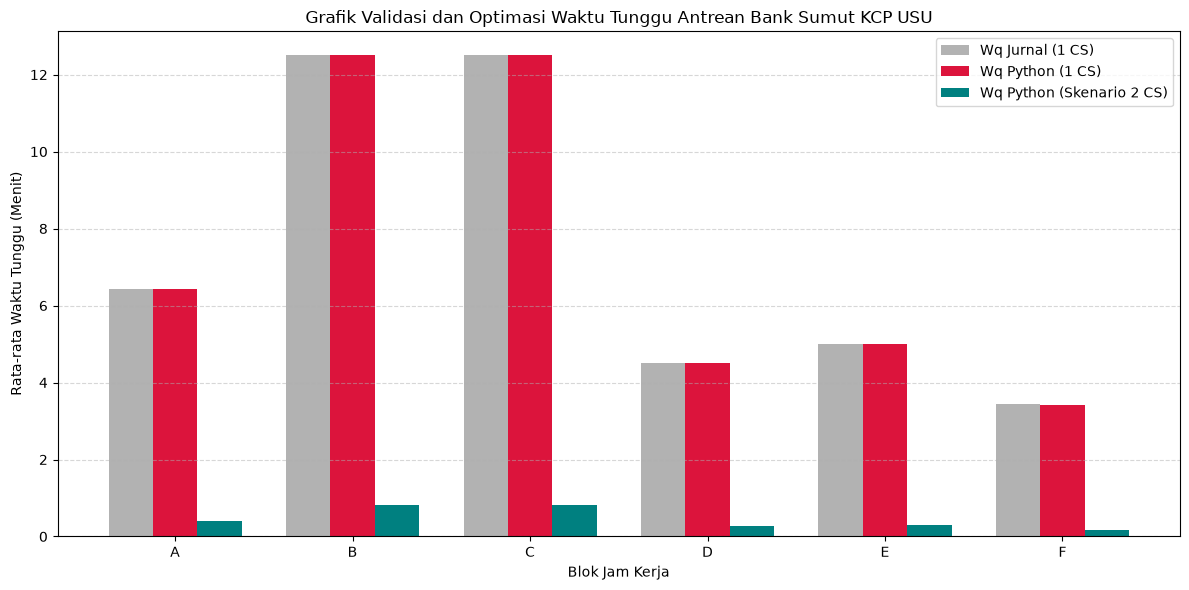

In [4]:
plt.figure(figsize=(12, 6))
x = np.arange(len(dfAntrean['blok_jam']))
width = 0.25

plt.bar(x - width, dfValidationComparison['wq_jurnal_minutes'], width, label='Wq Jurnal (1 CS)', color='gray', alpha=0.6)
plt.bar(x, dfValidationComparison['wq_python_minutes'], width, label='Wq Python (1 CS)', color='crimson')
plt.bar(x + width, dfSkenarioBaru['wq_minutes'], width, label='Wq Python (Skenario 2 CS)', color='teal')

plt.xlabel('Blok Jam Kerja')
plt.ylabel('Rata-rata Waktu Tunggu (Menit)')
plt.title('Grafik Validasi dan Optimasi Waktu Tunggu Antrean Bank Sumut KCP USU')
plt.xticks(x, dfAntrean['blok_jam'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()